Loading data from cache...
Best config:
{'k_regimes': 2, 'order': 1, 'switching_variance': True, 'trend': 'c', 'switching_ar': False}

Tuning table:
   k_regimes  order  switching_variance          aic          bic  \
0          2      1                True -6445.883321 -6411.154249   
1          2      2                True -6449.537093 -6409.854311   
2          2      1               False -6141.617231 -6111.849455   
3          2      2               False -6025.481525 -5990.759091   

           llf error  
0  3229.941660  None  
1  3232.768547  None  
2  3076.808616  None  
3  3019.740762  None  

Validation metrics:
{'MSE': 5.7166675538702744e-05, 'MAE': 0.0059447961821535574, 'RMSE': 0.00756086473485029, 'Directional_Accuracy': 0.5575221238938053}

Regime persistence metrics:
   regime      p_ii  expected_duration
0       0  0.974493          39.205682
1       1  0.949225          19.694622

Regime interpretability metrics:
   regime  n_obs  mean_return  std_return
0       0   

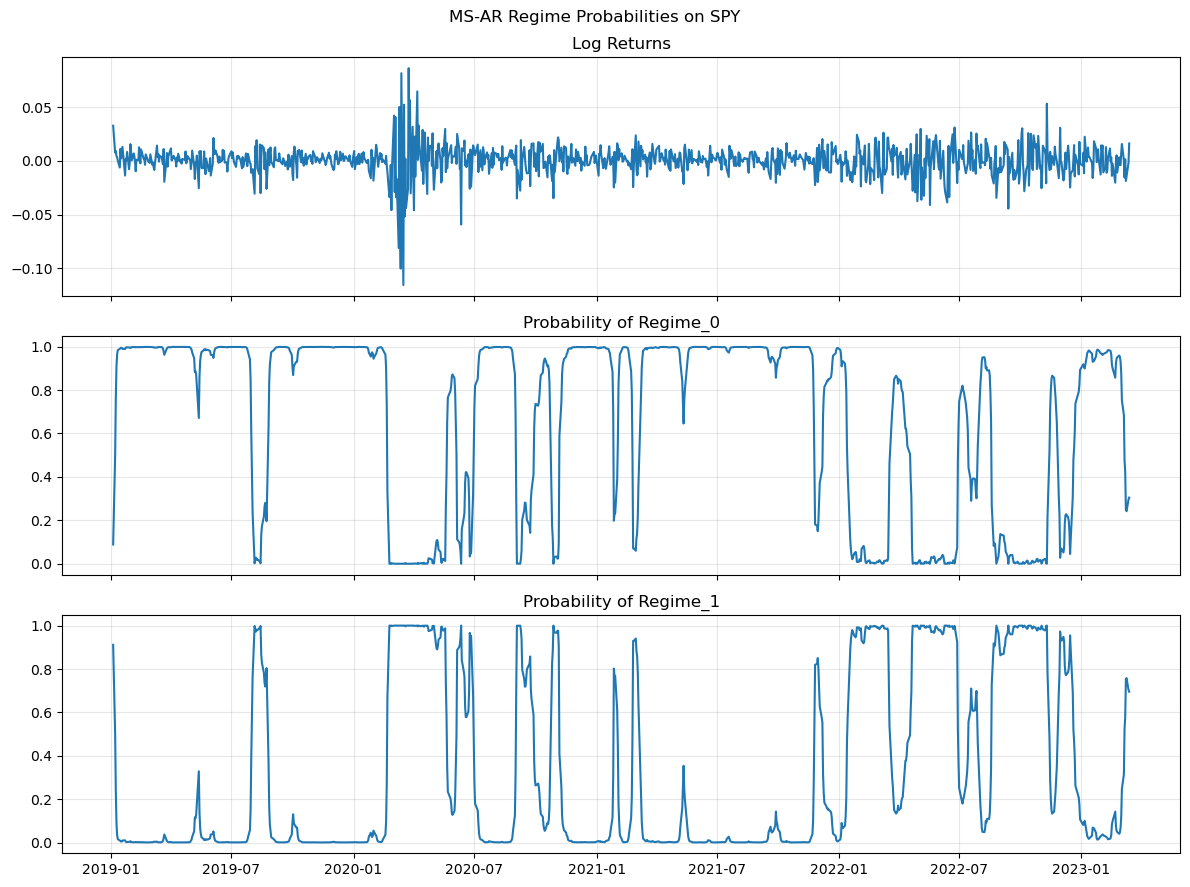

In [2]:
from model_utils import MSARConfig, run_full_msar_pipeline, plot_regime_probabilities

config = MSARConfig(
    ticker="SPY",
    start_date="2019-01-01",
    end_date="2025-01-01",
    train_ratio=0.7,
    val_ratio=0.15,
    k_regimes=2,
    order=1,
    trend="c",
)

outputs = run_full_msar_pipeline(config)

print("Best config:")
print(outputs["best_config"])
print("\nTuning table:")
print(outputs["tuning_table"])
print("\nValidation metrics:")
print(outputs["validation_metrics"])
print("\nRegime persistence metrics:")
print(outputs["regime_persistence_metrics"])
print("\nRegime interpretability metrics:")
print(outputs["regime_interpretability_metrics"])
print("\nRegime stress alignment metrics:")
print(outputs["regime_stress_alignment_metrics"])

plot_regime_probabilities(
    outputs["best_result"],
    outputs["train"]["return"],
    title="MS-AR Regime Probabilities on SPY"
)